# Graph AML Detector: Exploratory Data Analysis (EDA)

**Date:** 2026-06-06  
**Author:** Luis Renteria Lezano  
[LinkedIn](https://www.linkedin.com/in/renteria-luis) | [GitHub](https://github.com/renteria-luis)

---
## Executive Summary
- **Goal:** Test whether graph structure adds signal for detecting illicit Bitcoin transactions, by comparing a GraphSAGE GNN against an XGBoost tabular baseline on the same features.
- **Source:** [The Elliptic Data Set (Weber et al., 2019)](https://arxiv.org/abs/1908.02591), loaded via PyTorch Geometric's `EllipticBitcoinDataset`.
- **Data:** ~204K transactions as nodes, ~234K directed fund-flow edges, 165 anonymized features plus a time step (1 to 49); labels are ~2% illicit, ~21% licit, the rest unlabeled.

## Reproducibility & Environment Setup

In [24]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

from torch_geometric.datasets import EllipticBitcoinDataset

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx

SEED = 42
np.random.seed(SEED)

# Paths
DATA = Path('../data')
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')

## 1. Introduction

The Elliptic Data Set is a graph of real Bitcoin transactions released by Elliptic with the MIT-IBM Watson AI Lab (Weber et al., 2019). Each node is a transaction and each directed edge is a flow of funds from one transaction to the next. The task is to classify each transaction as licit or illicit.

There are three Elliptic datasets, solving different problems:

- Elliptic (2019), used here: ~204K transactions, node-level licit/illicit classification.
- Elliptic++: extends the original with actor and wallet nodes, making it a heterogeneous graph.
- Elliptic2 (2024): a much larger graph (~49M nodes, ~196M edges) for subgraph classification, detecting the shapes of laundering rather than single transactions.

This project uses the original. Its task, flagging an individual transaction, matches the detect-then-investigate design; its scale fits a single 6 GB GPU with neighbor sampling; and it loads directly through PyTorch Geometric. Elliptic++ would pull in heterogeneous GNNs and Elliptic2 a different, subgraph-level task, both beyond scope here.

> The dataset consists of 49 snapshots (timesteps), each one is a 3-hour period taken every two weeks. The actual blockchain is, of course, continuously connected in between those snapshots, but the dataset does not include the intermediate transactions. As a result, the graphs appear as disconnected islands. The paper explicitly describes the dataset as **49 directed acyclic graphs associated with distinct sequential points in time**.

## 2. Data Load & Overview

In [2]:
# First run downloads the three CSVs into data/raw/ and builds a processed
# data.pt in data/processed/. root='data' matches the repo layout, and data/
# is already gitignored.
dataset = EllipticBitcoinDataset(root=DATA)
data = dataset[0]
print(data)
print('features:', data.num_features)

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
features: 165


In [3]:
# The features file has no header: column 0 is txId, column 1 is the time
# step (1 to 49), and the rest are the anonymized features.
features = pd.read_csv(f'{DATA_RAW}/elliptic_txs_features.csv', header=None)
print('Raw features shape:', features.shape)
features.columns = ['txId', 'time_step'] + [f'feat_{i}' for i in range(1, features.shape[1] - 1)]

# classes and edgelist do have headers
classes = pd.read_csv(f'{DATA_RAW}/elliptic_txs_classes.csv')   # txId, class
edges = pd.read_csv(f'{DATA_RAW}/elliptic_txs_edgelist.csv')    # txId1, txId2

print('classes:', classes.shape)
print('edges:', edges.shape)
print('raw class values:', classes['class'].unique())

Raw features shape: (203769, 167)
classes: (203769, 2)
edges: (234355, 2)
raw class values: <ArrowStringArray>
['unknown', '2', '1']
Length: 3, dtype: str


In [4]:
# In the raw files, '1' is illicit, '2' is licit, 'unknown' is unlabeled.
# astype(str) guards against the column being read as ints.
label_names = {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
classes['label'] = classes['class'].astype(str).map(label_names)

counts = classes['label'].value_counts()
total = len(classes)
print(counts)
print((counts / total * 100).round(2))

labeled = counts['illicit'] + counts['licit']
print('illicit share of labeled:', round(counts['illicit'] / labeled * 100, 2), '%')

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64
label
unknown    77.15
licit      20.62
illicit     2.23
Name: count, dtype: float64
illicit share of labeled: 9.76 %


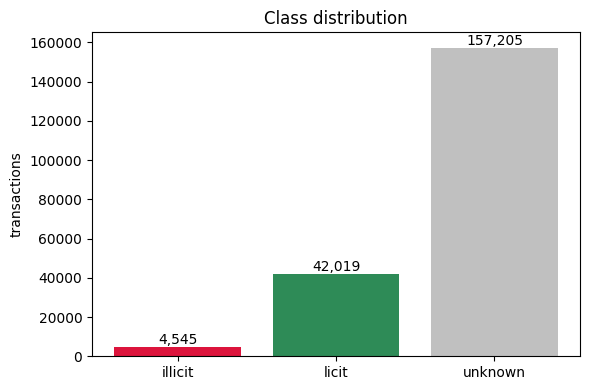

In [5]:
order = ['illicit', 'licit', 'unknown']
colors = ['crimson', 'seagreen', 'silver']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order, [counts[k] for k in order], color=colors)
ax.set_ylabel('transactions')
ax.set_title('Class distribution')
for i, k in enumerate(order):
    ax.text(i, counts[k], f'{counts[k]:,}', ha='center', va='bottom')
fig.tight_layout()

## 3. Temporal structure

Each transaction carries a time step from 1 to 49, spaced about two weeks apart. This section looks at how transaction volume and illicit activity move across those steps. The dataset is non-stationary, and that is what dictates the train/test split.

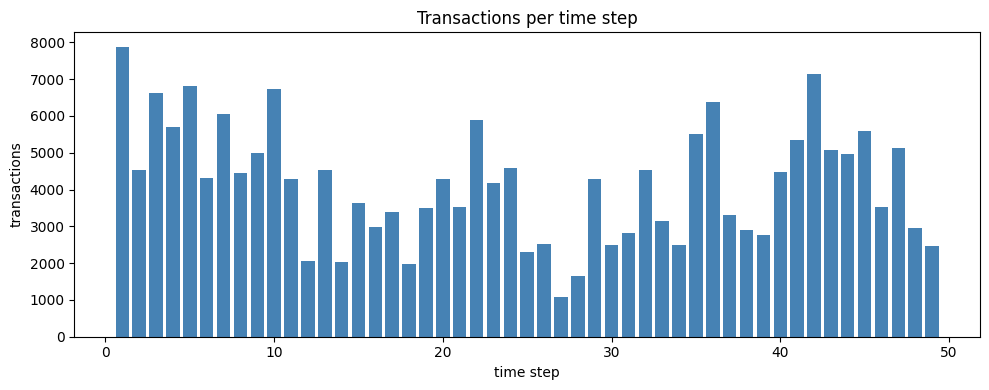

In [6]:
nodes_per_step = features['time_step'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(nodes_per_step.index, nodes_per_step.values, color='steelblue')
ax.set_xlabel('time step')
ax.set_ylabel('transactions')
ax.set_title('Transactions per time step')
fig.tight_layout()

In [7]:
tx = features[['txId', 'time_step']].merge(classes[['txId', 'label']], on='txId')
per_step = tx.groupby('time_step')['label'].value_counts().unstack(fill_value=0)
per_step['labeled'] = per_step['illicit'] + per_step['licit']
per_step['illicit_rate'] = per_step['illicit'] / per_step['labeled'].replace(0, np.nan)
# per_step[['illicit', 'licit', 'unknown', 'illicit_rate']]

In [8]:
# display the splitted dataframe
disp = per_step.copy()
disp['illicit_rate'] = (disp['illicit_rate'] * 100).round(1).astype(str) + '%'

dispT = disp.T
half = (dispT.shape[1] + 1) // 2

display(dispT.iloc[:, :half])
display(dispT.iloc[:, half:])

time_step,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
label,,,,,,,,,,,,,,,,,,,,,
illicit,17,18,11,30,8,5,102,67,248,18,...,128,99,52,80,260,100,158,53,137,118
licit,2130,1099,1268,1410,1874,480,1101,1098,530,954,...,402,712,337,665,640,541,1605,1134,989,476
unknown,5733,3427,5342,4253,4921,3843,4845,3292,4218,5755,...,2445,2574,1587,2761,3391,2896,4131,2978,3466,1720
labeled,2147,1117,1279,1440,1882,485,1203,1165,778,972,...,530,811,389,745,900,641,1763,1187,1126,594
illicit_rate,0.8%,1.6%,0.9%,2.1%,0.4%,1.0%,8.5%,5.8%,31.9%,1.9%,...,24.2%,12.2%,13.4%,10.7%,28.9%,15.6%,9.0%,4.5%,12.2%,19.9%


time_step,26,27,28,29,30,31,32,33,34,35,...,40,41,42,43,44,45,46,47,48,49
label,,,,,,,,,,,,,,,,,,,,,
illicit,96,24,85,329,83,106,342,23,37,182,...,112,116,239,24,24,5,2,22,36,56
licit,421,182,199,845,441,604,981,418,478,1159,...,1099,1016,1915,1346,1567,1216,710,824,435,420
unknown,2006,883,1369,3101,1959,2106,3202,2710,1971,4166,...,3270,4210,4986,3693,3384,4377,2807,4275,2483,1978
labeled,517,206,284,1174,524,710,1323,441,515,1341,...,1211,1132,2154,1370,1591,1221,712,846,471,476
illicit_rate,18.6%,11.7%,29.9%,28.0%,15.8%,14.9%,25.9%,5.2%,7.2%,13.6%,...,9.2%,10.2%,11.1%,1.8%,1.5%,0.4%,0.3%,2.6%,7.6%,11.8%


In [9]:
step_of = features.set_index('txId')['time_step']
e = edges.assign(t1=edges['txId1'].map(step_of), t2=edges['txId2'].map(step_of))
crossing = int((e['t1'] != e['t2']).sum())
print('edges crossing time steps:', crossing, 'of', len(e))

edges crossing time steps: 0 of 234355


### Findings

- The illicit rate among labeled transactions is highly non-stationary, ranging from 0.3% (step 46) to 36% (step 13). The global 9.76% figure averages over regimes that look nothing alike, and illicit activity arrives in bursts (steps 9, 13, 20, 28-29, 32).
- A regime break occurs at step 43: illicit counts collapse from 239 (step 42) to 24, bottoming at 2 (step 46). The original paper attributes this to the sudden shutdown of a dark market.
- No edge crosses time steps (0 of 234,355), so the graph is 49 isolated components and message passing only reads within-step structure. A temporal split therefore separates the train and test subgraphs completely.
- Modeling consequence: train on steps 1-34, test on 35-49. The labeled illicit rate drops from about 11.6% in train to 6.5% in test, and the test window contains the regime break, so evaluation measures generalization to a changed illicit landscape, as in production.

In [10]:
train = per_step.loc[1:34]
test = per_step.loc[35:49]

train_rate = train['illicit'].sum() / train['labeled'].sum()
test_rate = test['illicit'].sum() / test['labeled'].sum()

print(f"Train illicit rate: {train_rate:.4%}")
print(f"Test illicit rate:  {test_rate:.4%}")

Train illicit rate: 11.5809%
Test illicit rate:  6.4967%


### Strategy

I use a temporal split (train: time steps 1–34, test: 35–49) because it prevents two types of leakage.

First, **distributional leakage**. The dataset is non-stationary: the proportion of illicit transactions varies dramatically across time steps, ranging from 0.3% to 36%, with a clear regime shift at **t = 43** following the shutdown of a dark market. With a random split, the model is trained on samples from all regimes, artificially inflating performance metrics (the training set contains 11.6% illicit transactions versus 6.5% in the test set). In a real deployment, however, the model is always trained on past data and must predict on a future regime it has never observed.

Second, **structural leakage**. In graph neural networks, a random node split allows message passing during training to aggregate information from test nodes through graph edges. In the Elliptic dataset, however, no edges connect different time steps (0 out of 234,355 edges). Consequently, a temporal split completely separates the train and test subgraphs, eliminating this source of leakage. It is important to note that this complete separation is a property of the Elliptic dataset itself, not of temporal splits in general.


## 4. Graph structure and connectivity

Degree tells how connected each transaction is:
- in-degree, counts the transactions whose outputs it spends
- out-degree, counts the transactions that spend its outputs.

This section looks at the degree distribution, the largest hubs, whether degree differs by class, and verifies the claim that each time step is a single connected component.  

This section will help us answer: how connected the graph is (is there enough structure for a GNN to learn meaningful patterns?), and more importantly, whether the degree differs by class. If illicit transactions show a different connectivity profile compared to legitimate ones, this becomes the first empirical evidence supporting the design assumption: that graph structure carries signal that tabular features alone do not capture.

In [11]:
out_deg = edges['txId1'].value_counts()
in_deg = edges['txId2'].value_counts()

deg = features[['txId', 'time_step']].copy()
deg['in_deg'] = deg['txId'].map(in_deg).fillna(0).astype(int)
deg['out_deg'] = deg['txId'].map(out_deg).fillna(0).astype(int)
deg['degree'] = deg['in_deg'] + deg['out_deg']
deg = deg.merge(classes[['txId', 'label']], on='txId')

deg[['in_deg', 'out_deg', 'degree']].describe().round(2)

,in_deg,out_deg,degree
count,203769.00,203769.00,203769.00
mean,1.15,1.15,2.30
std,3.91,1.89,4.33
min,0.00,0.00,1.00
25%,0.00,1.00,1.00
50%,1.00,1.00,2.00
75%,1.00,1.00,2.00
max,284.00,472.00,473.00


> 75% of the graph is almost linear, with 1 incoming connection and 1 outgoing connection, resulting in a degree of 2. And no isolated nodes (min=0)

### 4.1 Nodes Degree Count

In [12]:
# fraction of graph has degree 2 or less
print('share with degree <= 2:', round((deg['degree'] <= 2).mean(), 3))
# top 10 most connected nodes and its class (hubs)
deg.nlargest(15, 'degree')[['txId', 'time_step', 'in_deg', 'out_deg', 'degree', 'label']]

share with degree <= 2: 0.79


,txId,time_step,in_deg,out_deg,degree,label
94301,2984918,22,1,472,473,licit
130,89273,1,1,288,289,licit
51371,43388675,10,284,0,284,licit
51437,68705820,10,247,0,247,licit
148292,30699343,37,241,0,241,licit
35892,96576418,7,239,0,239,licit
24761,225859042,5,212,0,212,unknown
19138,279187194,4,211,0,211,licit
58098,234890810,11,199,0,199,unknown
189738,196107869,46,188,0,188,licit


### 4.2 Degree Distribution

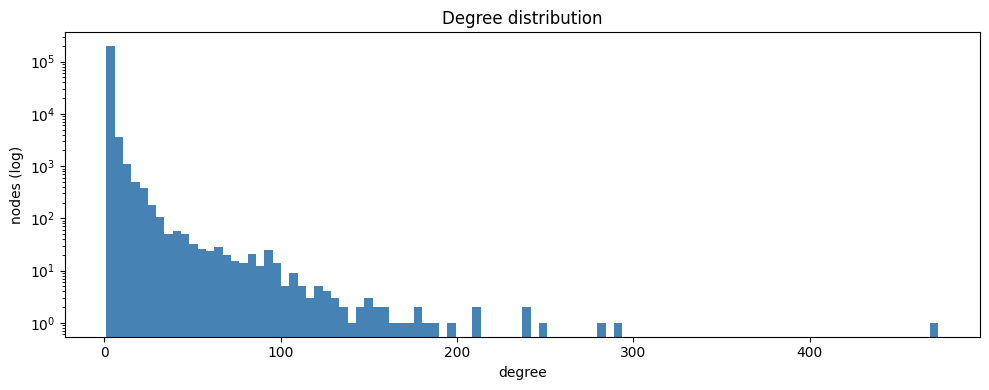

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(deg['degree'], bins=100, color='steelblue', log=True)
ax.set_xlabel('degree')
ax.set_ylabel('nodes (log)')
ax.set_title('Degree distribution')
fig.tight_layout()

### 4.3 Per Class Degree

In [14]:
deg.groupby('label')[['in_deg', 'out_deg', 'degree']].agg(['mean', 'median', 'max']).round(2)

in_deg             out_deg             degree            
          mean median  max    mean median  max   mean median  max
label                                                            
illicit   1.27    1.0  177    0.74    1.0    3   2.01    1.0  177
licit     1.91    1.0  284    1.19    1.0  472   3.10    2.0  473
unknown   0.94    1.0  212    1.15    1.0  122   2.10    2.0  212

### 4.4 Connected Component Count

A connected component refers to a subgraph in which all nodes are reachable from each other. In a strongly connected component, reachability respects edge direction (transaction flow). In a weakly connected component, edge direction is ignored and connectivity is evaluated on the undirected version of the graph.

According to the paper, the 49 graphs form a single weakly connected component. Here we verify this empirically.

In [15]:
comps = {}
for t, grp in features.groupby('time_step'):
    sub = edges[edges['txId1'].isin(grp['txId'])]
    g = nx.from_pandas_edgelist(sub, 'txId1', 'txId2', create_using=nx.DiGraph)
    g.add_nodes_from(grp['txId'])
    comps[t] = nx.number_weakly_connected_components(g)

comps = pd.Series(comps)
print('steps with a single component:', int((comps == 1).sum()), 'of', len(comps))

steps with a single component: 49 of 49


### Findings

- The degree distribution is heavy-tailed: 79% of transactions have degree <= 2 (median 2) while the largest hub reaches 473. Minimum degree is 1, so no node is isolated, consistent with every time step forming a single weakly connected component (49 of 49, verified; strong connectivity is meaningless here since each step is a DAG).
- Hubs come in two shapes, both matching exchange-style batching: consolidation hubs (in-degree up to 284, many parents, no spenders yet) and payout hubs (the top node has in-degree 1 and out-degree 472, one transaction funding hundreds of later ones).
- Top hubs are overwhelmingly licit or unknown. Two illicit consolidation hubs appear (in-degree 177 and 173), but no illicit payout hubs: the maximum illicit out-degree is 3 versus 472 for licit. Out-degrees are floors, since spends outside each ~3 hour snapshot are not captured, but the licit/illicit asymmetry is still informative.
- Degree alone already separates classes (illicit median degree 1 vs licit 2, lower means on both sides), so connectivity carries class signal before any model is trained. This supports the core bet that graph structure adds value over tabular features.
- Modeling consequence: hubs make neighborhoods explode multiplicatively with hops (one hub at hop 1 pulls in hundreds of nodes at hop 2). Neighbor sampling caps per-hop fan-in, which is what keeps GraphSAGE mini-batches inside the 6 GB budget.

## 5. Feature analysis

The 165 features are anonymized, so no domain interpretation is possible. What can be checked: their scale, their composition (the paper describes the first 94 as local transaction information and the remaining 72 as one-hop neighborhood aggregates), redundancy, and whether individual features already separate the classes, which anticipates how strong the tabular baseline will be.

> Features are anonymized, so this is inferred from the paper’s counts and cannot be verified column by column:
> - Local features: feat_1 to feat_93
> - aggregated features: feat_94 to feat_165.


### 5.1 Scale checking
We compute the mean and standard deviation of each feature and summarize them, so we can check whether the features are pre-standardized (mean = 0, std = 1). Since XGBoost is a tree-based model, it is not sensitive to feature scaling because it relies on threshold splits. However, GNNs require standardized inputs.

In [16]:
feat_cols = [c for c in features.columns if c.startswith('feat_')]
X = features[feat_cols]

scale = pd.DataFrame({'mean': X.mean(), 'std': X.std()})
scale.describe().round(3)

,mean,std
count,165.0,165.0
mean,0.0,1.0
std,0.0,0.0
min,-0.0,1.0
25%,-0.0,1.0
50%,0.0,1.0
75%,0.0,1.0
max,0.0,1.0


### 5.2 Local and Aggregated cut

In [17]:
local_cols = feat_cols[:93]
agg_cols = feat_cols[93:]
print(len(local_cols), 'local features,', len(agg_cols), 'aggregated features')

93 local features, 72 aggregated features


### 5.3 Class Separability
Build the illicit and licit subsets (discarding unknown), computes Cohen’s d for each feature with a guard for zero-variance features (resulting in NaNs instead of failures), and ranks the top 10 features with the highest class separation.

In [18]:
labeled = features.merge(classes[['txId', 'label']], on='txId')
labeled = labeled[labeled['label'] != 'unknown']

ill = labeled[labeled['label'] == 'illicit'][feat_cols]
lic = labeled[labeled['label'] == 'licit'][feat_cols]

pooled_std = np.sqrt((ill.var() + lic.var()) / 2).replace(0, np.nan)

# cohen’s d
effect = ((ill.mean() - lic.mean()).abs() / pooled_std).sort_values(ascending=False)
effect.head(10)

feat_53     1.162276
feat_55     0.996839
feat_89     0.990204
feat_90     0.987356
feat_91     0.757737
feat_52     0.748549
feat_150    0.684774
feat_54     0.636636
feat_114    0.573780
feat_83     0.552977
dtype: float64

### 5.4 Distributions of the top features by class
Overlapping histograms of the 4 features with the highest Cohen’s d, comparing licit vs illicit. Each axis is clipped to the 0.5–99.5 percentile range for visualization only to avoid a single outlier squash the entire histogram toward the left.

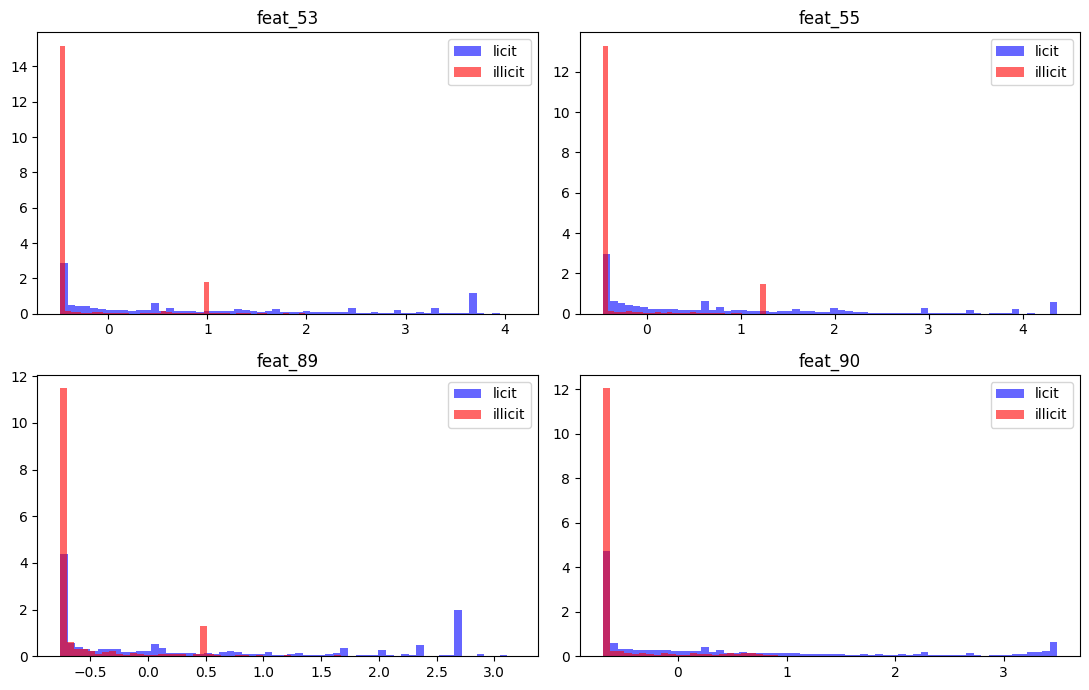

In [19]:
top = effect.index[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), top):
    both = pd.concat([lic[col], ill[col]])
    lo, hi = both.quantile([0.005, 0.995])
    ax.hist(lic[col].loc[lic[col].between(lo, hi)], bins=60, alpha=0.6,
            color='blue', density=True, label='licit')
    ax.hist(ill[col].loc[ill[col].between(lo, hi)], bins=60, alpha=0.6,
            color='red', density=True, label='illicit')
    ax.set_title(col)
    ax.legend()
fig.tight_layout()

### 5.5 Redundancy
The number indicates how many pairs of features are nearly identical columns. A high number is expected, since the aggregated features are derived from the local ones.


In [20]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
print('pairs with |corr| > 0.95:', int((upper > 0.95).sum().sum()))

pairs with |corr| > 0.95: 96


### Findings

- All 165 features arrive standardized (mean 0, std 1 across the board), done globally by the dataset creators. No further scaling is needed; this matters for the GNN, while trees are scale-invariant anyway.
- Univariate signal is strong: four features reach an effect size near or above 1.0 (feat_53 at 1.16), and the top separators are local features (feat_1-93), not neighborhood aggregates. The tabular baseline should be competitive.
- Class distributions of the top features show illicit mass concentrated in narrow low-value spikes while licit spreads widely: illicit activity looks homogeneous, consistent with a single dominant actor behind most illicit labels.
- 96 of ~13.5K feature pairs are near-duplicates (|corr| > 0.95), expected since aggregated features derive from local ones. No pruning needed for trees or the GNN.
- Baseline design consequence: XGBoost will be reported in two configurations, local features only (the pure tabular test of whether structure adds value) and all 165 (the strong baseline already containing fixed one-hop aggregates, where the GNN must prove that learned, multi-hop aggregation beats hand-crafted statistics).

## 6. Data quality

Standard integrity checks: missing values, duplicates, referential integrity between the three files, and self-loops (a transaction cannot spend its own outputs, so the graph should have none).

In [21]:
print('missing in features:', int(features.isna().sum().sum()))
print('missing in classes:', int(classes.isna().sum().sum()))
print('missing in edges:', int(edges.isna().sum().sum()))

missing in features: 0
missing in classes: 0
missing in edges: 0


In [22]:
print('duplicate txIds in features:', int(features['txId'].duplicated().sum()))
print('duplicate txIds in classes:', int(classes['txId'].duplicated().sum()))
print('duplicate edges:', int(edges.duplicated().sum()))

duplicate txIds in features: 0
duplicate txIds in classes: 0
duplicate edges: 0


In [23]:
known = set(features['txId'])
dangling = int((~edges['txId1'].isin(known)).sum() + (~edges['txId2'].isin(known)).sum())
print('edge endpoints missing from features:', dangling)
print('self-loops:', int((edges['txId1'] == edges['txId2']).sum()))
print('classes covers all transactions:', set(classes['txId']) == known)

edge endpoints missing from features: 0
self-loops: 0
classes covers all transactions: True


## 7. Findings and modeling implications

**Task and data.** The Elliptic dataset contains ~204K Bitcoin transactions (nodes) and ~234K directed fund flows (edges), with 165 anonymized features per node: 93 local to the transaction and 72 fixed one-hop neighborhood aggregates. 2.2% of nodes are labeled illicit, 20.6% licit, the rest unlabeled. The task is to classify transactions as illicit.

**Imbalance drives the metric.** Among labeled nodes, illicit is 9.8%. A model predicting licit for everything reaches 90% accuracy with 0% recall, so accuracy is meaningless. PR-AUC is the primary metric: it summarizes the precision-recall tradeoff across thresholds and is centered on the positive class, unlike ROC-AUC, which the overwhelming negative class inflates. Precision and recall at an operating threshold are reported as secondary metrics, since recall alone is trivially gamed by flagging everything.

**Non-stationarity drives the split.** The illicit rate per step ranges from 0.3% to 36%, with a regime break at step 43 (illicit counts collapse from 239 to 24 and stay low), attributed to a dark market shutdown. A random split would let the model train on every regime, including post-break, inflating the metric. The temporal split (train on steps 1-34, test on 35-49) evaluates what production demands: training on the past and predicting an unseen future regime. Train is 11.6% illicit vs 6.5% in test.

**Structure closes the second leakage channel.** No edge crosses time steps (0 of 234,355): the dataset is 49 disjoint graphs, each a single weakly connected component and a DAG, since outputs can only be spent after they exist. The temporal split therefore separates the train and test subgraphs completely, whereas a random split would let message passing during training aggregate features from test nodes.

**Hubs drive the sampling strategy.** The degree distribution is heavy-tailed: 79% of nodes have degree <= 2 while hubs reach 473, with exchange-style consolidation and payout shapes. A single hub in a neighborhood makes receptive fields explode multiplicatively with hops, ruling out full-batch training on 6 GB. GraphSAGE caps the per-hop fan-in by sampling a fixed number of neighbors uniformly at random, keeping mini-batches within budget.

**Structure already carries signal.** Degree alone separates classes before any training: illicit median degree 1 vs licit 2, and a maximum illicit out-degree of 3 vs 472 for licit. On features, four reach an effect size near 1.0, mostly local ones, so the tabular baseline should be competitive.

**Baseline design.** XGBoost runs in two configurations: local features only (1-93), the purely tabular reference, and all 165, a strong baseline that already contains fixed one-hop aggregates. The comparisons answer different questions: XGBoost local vs all features asks whether hand-crafted structural information adds value; XGBoost with all features vs the GNN asks whether learned, multi-hop aggregation beats hand-crafted one-hop statistics.